In [1]:
# Setup: imports e configuração de ambiente
import os, sys

# Detecta se ta rodando no Colab ou local
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    REPO_URL = 'https://github.com/ROMAUSKI/tcc-analise-sentimento.git'
    NOME_REPO = 'tcc-analise-sentimento'
    try:
        os.chdir('/content')
    except:
        pass
    if not os.path.exists(NOME_REPO):
        !git clone $REPO_URL
    os.chdir(f'{NOME_REPO}/dados/brutos')
    print(f'Colab - diretorio: {os.getcwd()}')
else:
    # Local (VS Code) - vai pra dados/brutos a partir da raiz do projeto
    raiz = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
    os.chdir(os.path.join(raiz, 'dados', 'brutos'))
    print(f'Local - diretorio: {os.getcwd()}')

# Garante pasta resultados
os.makedirs('../../resultados', exist_ok=True)

# Imports
import pandas as pd
import numpy as np
import re
import glob
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)
from sklearn.model_selection import cross_val_score, learning_curve
from sklearn.pipeline import Pipeline

sns.set_style('whitegrid')
warnings.filterwarnings('ignore')

print('Ambiente pronto!')

Local - diretorio: C:\Users\Davi\Documents\TCC\tcc-analise-sentimento\dados\brutos


Ambiente pronto!


In [2]:
#Versões Atuais das Bibliotecas Instaladas
!pip freeze | grep -E "pandas|scikit-learn|matplotlib|seaborn|nltk|wordcloud"

matplotlib==3.10.8
matplotlib-inline==0.2.1
nltk==3.9.3
pandas==3.0.1
scikit-learn==1.8.0
seaborn==0.13.2
wordcloud==1.9.6


In [3]:
# Confirma diretorio de trabalho
print(f'Diretorio atual: {os.getcwd()}')
print(f'Arquivos: {os.listdir(".")}')

Diretorio atual: C:\Users\Davi\Documents\TCC\tcc-analise-sentimento\dados\brutos
Arquivos: ['metadata.csv', 'negative_claude_01.csv', 'negative_gemini_01.csv', 'negative_gpt_01.csv', 'neutral_claude_01.csv', 'neutral_gemini_01.csv', 'neutral_gpt_01.csv', 'positive_claude_01.csv', 'positive_gemini_01.csv', 'positive_gpt_01.csv']


In [4]:
#UNIFICAÇÃO DOS 9 ARQUIVOS

print("--- Iniciando script de unificação ---")

# 1. Encontrar todos os arquivos CSV
try:
    arquivos_csv = glob.glob('*.csv')
    # Remove arquivos que não são dados brutos
    for arq_ignorar in ['metadata.csv', 'dataset_completo.csv', 'synthetic_dataset.csv']:
        if arq_ignorar in arquivos_csv:
            arquivos_csv.remove(arq_ignorar)

except ValueError:
    print("Aviso: Falha ao remover arquivos, processando todos os CSVs.")

print(f"Arquivos encontrados para unificação: {arquivos_csv}")

lista_dataframes = []

# 2. Loop para ler cada arquivo
for arquivo in arquivos_csv:
    try:
        # Leitura forçando a primeira coluna (correção do bug do GPT)
        df_temp = pd.read_csv(
            arquivo,
            header=None,
            names=['frase'],
            usecols=[0]
        )

        # Limpeza básica (nulos e vazios)
        df_temp = df_temp.dropna(subset=['frase'])
        df_temp['frase'] = df_temp['frase'].astype(str)
        df_temp = df_temp[df_temp['frase'].str.strip() != ""]

        # Adiciona metadados
        nome_arquivo = arquivo.split('.')[0]

        if 'positive' in nome_arquivo: df_temp['classe'] = 'Positiva'
        elif 'negative' in nome_arquivo: df_temp['classe'] = 'Negativa'
        elif 'neutral' in nome_arquivo: df_temp['classe'] = 'Neutra'
        else: df_temp['classe'] = 'Desconhecida'

        if '_gemini_' in nome_arquivo: df_temp['fonte'] = 'Gemini'
        elif '_gpt_' in nome_arquivo: df_temp['fonte'] = 'ChatGPT'
        elif '_claude_' in nome_arquivo: df_temp['fonte'] = 'Claude'
        else: df_temp['fonte'] = 'Desconhecida'

        lista_dataframes.append(df_temp)

    except Exception as e:
        print(f"Erro ao ler o arquivo {arquivo}: {e}")

# 3. Combinar tudo
df_final = pd.concat(lista_dataframes, ignore_index=True)

# 4. Embaralhar (COM SEED FIXA)
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

# 5. Salvar na pasta processado
df_final.to_csv('../processado/dataset_completo.csv', index=False)

# 6. Mostrar resumo
print("\n--- Processamento Concluído! ---")
print(f"Total de frases no dataset final: {len(df_final)}")
print("\nDistribuição por Classe:")
print(df_final['classe'].value_counts())

--- Iniciando script de unificação ---
Arquivos encontrados para unificação: ['negative_claude_01.csv', 'negative_gemini_01.csv', 'negative_gpt_01.csv', 'neutral_claude_01.csv', 'neutral_gemini_01.csv', 'neutral_gpt_01.csv', 'positive_claude_01.csv', 'positive_gemini_01.csv', 'positive_gpt_01.csv']

--- Processamento Concluído! ---
Total de frases no dataset final: 1800

Distribuição por Classe:
classe
Positiva    600
Neutra      600
Negativa    600
Name: count, dtype: int64


In [5]:
#PRÉ PROCESSAMENTO (LIMPEZA)

print("--- Iniciando Etapa de Pré-processamento ---")

# 1. Carregar o dataset unificado que acabamos de criar
try:
    df = pd.read_csv('../processado/dataset_completo.csv')
    print(f"Dataset 'dataset_completo.csv' carregado. Total de {len(df)} linhas.")
except FileNotFoundError:
    print("ERRO: Arquivo 'dataset_completo.csv' não encontrado!")

# 2. Verificação inicial (pré-limpeza)
print(f"Frases duplicadas encontradas (antes da limpeza): {df.duplicated(subset=['frase']).sum()}")

# 3. Função de Limpeza de Texto
def limpar_texto(texto):
    # Converte tudo para minúsculas
    texto = texto.lower()

    # Remove pontuação, números e caracteres especiais
    # Mantém apenas letras, espaços e acentos
    texto = re.sub(r'[^a-zÀ-ÿ\s]', '', texto)

    # Remove espaços extras (ex: "filme   bom" vira "filme bom")
    texto = re.sub(r'\s+', ' ', texto).strip()

    return texto

# 4. Aplicar a limpeza na coluna 'frase'
print("Aplicando limpeza (minúsculas, remoção de pontuação/números)...")
df['frase_limpa'] = df['frase'].apply(limpar_texto)

# 5. Verificação pós-limpeza
duplicatas_pos_limpeza = df.duplicated(subset=['frase_limpa']).sum()
print(f"Frases duplicadas encontradas (depois da limpeza): {duplicatas_pos_limpeza}")

# Remove efetivamente as duplicatas
df = df.drop_duplicates(subset=['frase_limpa']).reset_index(drop=True)

# 6. Salvar o dataset final e limpo na pasta processado
df_final_limpo = df[['frase_limpa', 'classe', 'fonte', 'frase']]
df_final_limpo.to_csv('../processado/synthetic_dataset.csv', index=False)

print("\n--- Pré-processamento Concluído! ---")
print(f"Dataset limpo salvo em 'dados/processado/synthetic_dataset.csv'.")
print(f"Total de frases únicas no dataset final: {len(df_final_limpo)}")
print("\n10 primeiras linhas do dataset limpo:")
print(df_final_limpo.rename(columns={'frase': 'frase_original'}).head(10))

--- Iniciando Etapa de Pré-processamento ---
Dataset 'dataset_completo.csv' carregado. Total de 1800 linhas.
Frases duplicadas encontradas (antes da limpeza): 2
Aplicando limpeza (minúsculas, remoção de pontuação/números)...
Frases duplicadas encontradas (depois da limpeza): 2

--- Pré-processamento Concluído! ---
Dataset limpo salvo em 'dados/processado/synthetic_dataset.csv'.
Total de frases únicas no dataset final: 1798

10 primeiras linhas do dataset limpo:
                                         frase_limpa    classe    fonte  \
0  este filme toca a alma de uma forma muito espe...  Positiva   Gemini   
1  o filme quem quer ser um milionário venceu oit...    Neutra   Gemini   
2  o termo cliffhanger se refere a um final de ep...    Neutra   Gemini   
3  o filme desperdiça premissa interessante com e...  Negativa   Claude   
4  a fotografia usa luz e sombra de maneira magis...  Positiva   Claude   
5  a cinematografia abusa de câmera tremida ao po...  Negativa   Claude   
6  as cen

--- Iniciando Etapa de Análise Estatística (com Violin Plot) ---
Dataset 'synthetic_dataset.csv' carregado. Total de 1798 frases.

--- ESTATÍSTICAS GERAIS DO DATASET ---
Número total de frases (amostras): 1798

--- Distribuição por Classe ---
classe
Positiva    600
Neutra      600
Negativa    598
Name: count, dtype: int64

--- Distribuição por Fonte (IA) ---
fonte
Gemini     600
Claude     600
ChatGPT    598
Name: count, dtype: int64

--- Estatísticas do Comprimento das Frases (Nº de Palavras) ---
Média de palavras por frase: 10.56
Mediana de palavras por frase: 10.0
Frase mais curta (palavras): 5
Frase mais longa (palavras): 17

Salvando gráficos na pasta 'resultados/'...


Gráfico 'distribuicao_classe_por_fonte.png' salvo.


Gráfico 'violino_comprimento_por_fonte.png' salvo.
Gráfico 'distribuicao_comprimento_frases.png' salvo.

--- Análise Estatística Concluída! ---


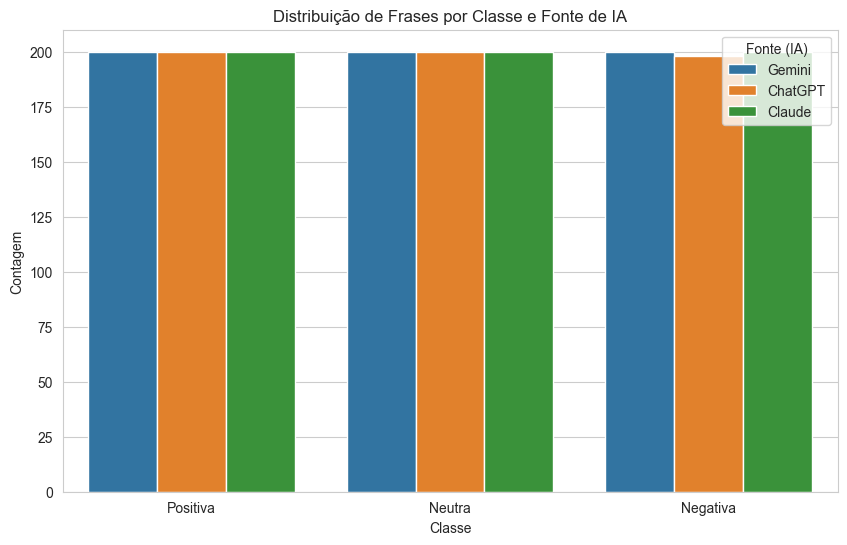

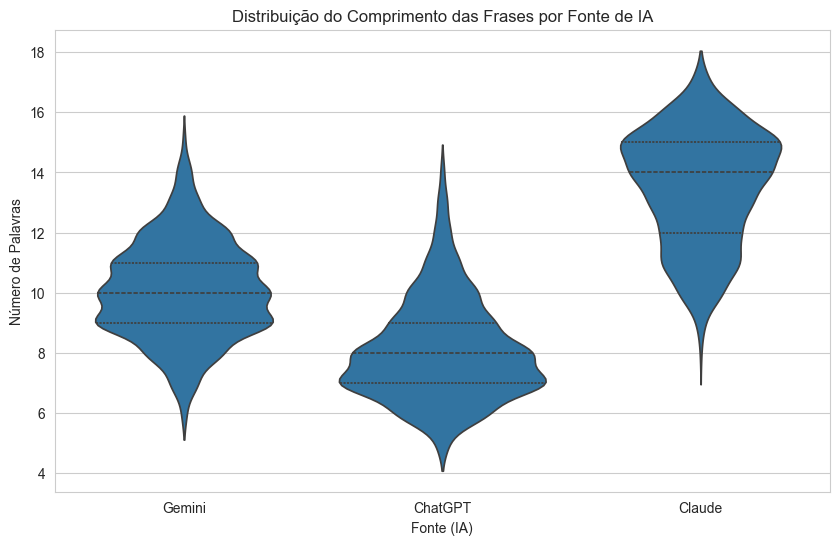

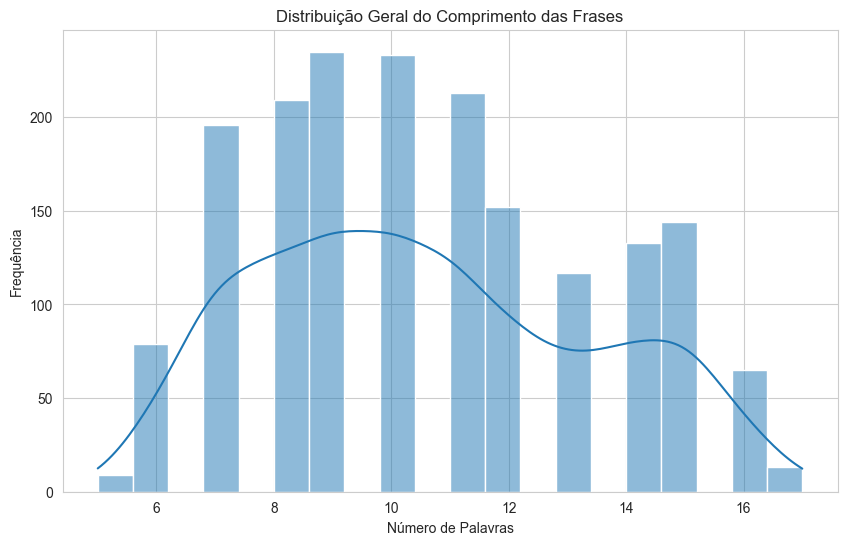

In [6]:
print("--- Iniciando Etapa de Análise Estatística (com Violin Plot) ---")

# 1. Carregar o dataset limpo
try:
    df = pd.read_csv('../processado/synthetic_dataset.csv')
    print(f"Dataset 'synthetic_dataset.csv' carregado. Total de {len(df)} frases.")
except FileNotFoundError:
    print("ERRO: Arquivo 'synthetic_dataset.csv' não encontrado! Rode a célula anterior primeiro.")
    raise

# 2. Calcular estatísticas de texto
df['num_palavras'] = df['frase_limpa'].apply(lambda x: len(str(x).split()))

# --- EXIBIÇÃO DAS ESTATÍSTICAS (TEXTO) ---
print("\n--- ESTATÍSTICAS GERAIS DO DATASET ---")
print(f"Número total de frases (amostras): {len(df)}")
print("\n--- Distribuição por Classe ---")
print(df['classe'].value_counts())
print("\n--- Distribuição por Fonte (IA) ---")
print(df['fonte'].value_counts())
print("\n--- Estatísticas do Comprimento das Frases (Nº de Palavras) ---")
print(f"Média de palavras por frase: {df['num_palavras'].mean():.2f}")
print(f"Mediana de palavras por frase: {df['num_palavras'].median()}")
print(f"Frase mais curta (palavras): {df['num_palavras'].min()}")
print(f"Frase mais longa (palavras): {df['num_palavras'].max()}")

# --- GERAÇÃO DE GRÁFICOS (AVANÇADOS) ---

# Define o caminho para salvar
pasta_resultados = "../../resultados/"
print("\nSalvando gráficos na pasta 'resultados/'...")

# --- Gráfico 1 (O Combinado): Barras Agrupadas ---
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x='classe',
    hue='fonte',
    order=['Positiva', 'Neutra', 'Negativa'],
    hue_order=['Gemini', 'ChatGPT', 'Claude']
)
plt.title('Distribuição de Frases por Classe e Fonte de IA')
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.legend(title='Fonte (IA)')
plt.savefig(f"{pasta_resultados}distribuicao_classe_por_fonte.png")
print(f"Gráfico 'distribuicao_classe_por_fonte.png' salvo.")

# --- Gráfico 2 (O "Mais Legal"): VIOLIN PLOT ---
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df,
    x='fonte',
    y='num_palavras',
    order=['Gemini', 'ChatGPT', 'Claude'],
    inner='quartile'
)
plt.title('Distribuição do Comprimento das Frases por Fonte de IA')
plt.xlabel('Fonte (IA)')
plt.ylabel('Número de Palavras')
plt.savefig(f"{pasta_resultados}violino_comprimento_por_fonte.png")
print(f"Gráfico 'violino_comprimento_por_fonte.png' salvo.")

# --- Gráfico 3 (O Útil): Histograma Geral ---
plt.figure(figsize=(10, 6))
sns.histplot(df['num_palavras'], bins=20, kde=True)
plt.title('Distribuição Geral do Comprimento das Frases')
plt.xlabel('Número de Palavras')
plt.ylabel('Frequência')
plt.savefig(f"{pasta_resultados}distribuicao_comprimento_frases.png")
print(f"Gráfico 'distribuicao_comprimento_frases.png' salvo.")

print("\n--- Análise Estatística Concluída! ---")

In [7]:
print("--- Iniciando Etapa 3: Preparação dos Modelos Baseline ---")

# --- [X] Carregar o synthetic_dataset.csv ---
try:
    df = pd.read_csv('../processado/synthetic_dataset.csv')
    print(f"Dataset 'synthetic_dataset.csv' carregado com {len(df)} linhas.")
except FileNotFoundError:
    print("ERRO: 'synthetic_dataset.csv' não encontrado! Rode as células anteriores.")
    raise
except Exception as e:
    print(f"Erro ao carregar o CSV: {e}")
    raise

# Garantir que não há nulos na coluna 'frase_limpa' (embora já tenhamos tratado)
df = df.dropna(subset=['frase_limpa'])

# 1. Definir X (features) e y (target)
X = df['frase_limpa']
y = df['classe']

# 2. Definir nossa "semente" (seed) para reprodutibilidade
# Isso é VITAL para o seu TCC. Garante que os resultados sejam sempre os mesmos.
RANDOM_SEED = 42

# --- [X] Dividir os dados em treino (80%) e teste (20%) ---
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y
)

print("\n--- Divisão Treino/Teste Concluída ---")
print(f"Amostras de Treino (X_train): {len(X_train)}")
print(f"Amostras de Teste (X_test):   {len(X_test)}")
print(f"Rótulos de Treino (y_train): {len(y_train)}")
print(f"Rótulos de Teste (y_test):   {len(y_test)}")

# --- [X] Implementar a vetorização com TF-IDF ---
print("\n--- Iniciando Vetorização TF-IDF ---")

tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Vetorização TF-IDF Concluída.")
print(f"Shape da Matriz TF-IDF de Treino: {X_train_tfidf.shape}")
print(f"Shape da Matriz TF-IDF de Teste:  {X_test_tfidf.shape}")
print(f"Número total de features (palavras únicas): {X_train_tfidf.shape[1]}")

--- Iniciando Etapa 3: Preparação dos Modelos Baseline ---
Dataset 'synthetic_dataset.csv' carregado com 1798 linhas.

--- Divisão Treino/Teste Concluída ---
Amostras de Treino (X_train): 1438
Amostras de Teste (X_test):   360
Rótulos de Treino (y_train): 1438
Rótulos de Teste (y_test):   360

--- Iniciando Vetorização TF-IDF ---
Vetorização TF-IDF Concluída.
Shape da Matriz TF-IDF de Treino: (1438, 3281)
Shape da Matriz TF-IDF de Teste:  (360, 3281)
Número total de features (palavras únicas): 3281


--- Etapa 3.2: Treinamento - Regressão Logística (Análise F1) ---
Treinando o modelo de Regressão Logística...
Treinamento concluído.

--- Relatório de Classificação (Completo) ---
              precision    recall  f1-score   support

    Negativa       0.87      0.77      0.81       120
      Neutra       0.82      0.89      0.85       120
    Positiva       0.83      0.85      0.84       120

    accuracy                           0.84       360
   macro avg       0.84      0.84      0.84       360
weighted avg       0.84      0.84      0.84       360


--- Veredito (O que importa pro TCC) ---
O F1-Score final (ponderado) do modelo foi: 0.8354 (ou 83.54%)
Gráfico 'f1_score_por_classe_lr.png' salvo em ../../resultados/


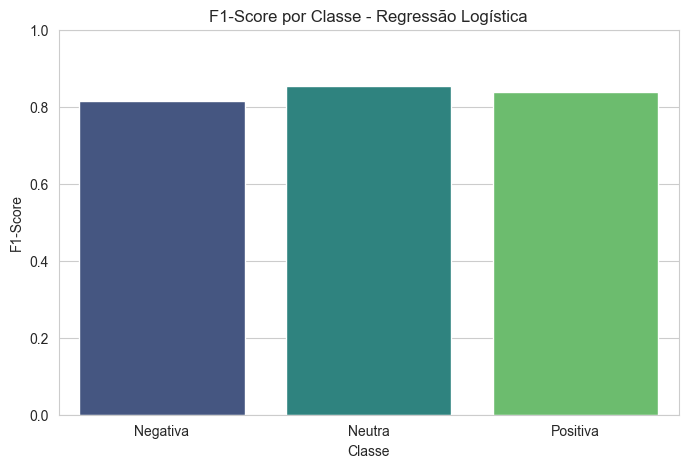


Gerando Matriz de Confusão...


Matriz 'matriz_confusao_lr.png' salva em ../../resultados/


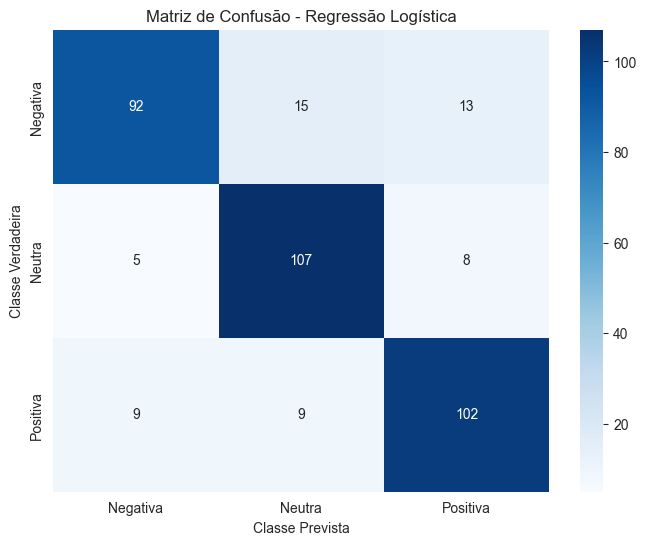


Resultados da Regressão Logística salvos.


In [8]:
print("--- Etapa 3.2: Treinamento - Regressão Logística (Análise F1) ---")

# 1. Inicializar e Treinar o modelo
model_lr = LogisticRegression(random_state=RANDOM_SEED)
print("Treinando o modelo de Regressão Logística...")
model_lr.fit(X_train_tfidf, y_train)
print("Treinamento concluído.")

# 2. Fazer previsões
y_pred_lr = model_lr.predict(X_test_tfidf)

# 3. Gerar Relatório
print("\n--- Relatório de Classificação (Completo) ---")
print(classification_report(y_test, y_pred_lr))

# 4. Gerar o Relatório como um Dicionário
report_dict = classification_report(y_test, y_pred_lr, output_dict=True)

# 5. Converter pra um DataFrame do Pandas
df_report = pd.DataFrame(report_dict).transpose()

# 6. Pegar só o F1-Score das 3 classes principais
f1_scores = df_report.loc[['Negativa', 'Neutra', 'Positiva'], 'f1-score']

# 7. Imprimir o F1-Score "Ponderado"
f1_final = report_dict['weighted avg']['f1-score']
print(f"\n--- Veredito (O que importa pro TCC) ---")
print(f"O F1-Score final (ponderado) do modelo foi: {f1_final:.4f} (ou {f1_final*100:.2f}%)")

# 8. Plotar o Gráfico de F1-Score por Classe
pasta_resultados = "../../resultados/"
plt.figure(figsize=(8, 5))
sns.barplot(
    x=f1_scores.index,
    y=f1_scores.values,
    palette='viridis',
    hue=f1_scores.index,
    legend=False
)
plt.title('F1-Score por Classe - Regressão Logística')
plt.xlabel('Classe')
plt.ylabel('F1-Score')
plt.ylim(0, 1.0)
plt.savefig(f"{pasta_resultados}f1_score_por_classe_lr.png")
print(f"Gráfico 'f1_score_por_classe_lr.png' salvo em {pasta_resultados}")
plt.show()

# Gerar Matriz de Confusão
print("\nGerando Matriz de Confusão...")
cm_lr = confusion_matrix(y_test, y_pred_lr)
labels = sorted(y.unique())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.title('Matriz de Confusão - Regressão Logística')
plt.xlabel('Classe Prevista')
plt.ylabel('Classe Verdadeira')
plt.savefig(f"{pasta_resultados}matriz_confusao_lr.png")
print(f"Matriz 'matriz_confusao_lr.png' salva em {pasta_resultados}")
plt.show()

# Armazena os resultados pro nosso dicionário
try:
    resultados_modelos
except NameError:
    resultados_modelos = {}

resultados_modelos['Regressão Logística'] = {
    'Acurácia': report_dict['accuracy'],
    'Precisão': report_dict['weighted avg']['precision'],
    'Recall': report_dict['weighted avg']['recall'],
    'F1-Score': f1_final
}

print("\nResultados da Regressão Logística salvos.")

--- Etapa 3.3: Treinamento - Naive Bayes (Multinomial) ---
Treinando o modelo Naive Bayes...
Treinamento concluído.

--- Relatório de Classificação (Naive Bayes) ---
              precision    recall  f1-score   support

    Negativa       0.86      0.84      0.85       120
      Neutra       0.90      0.88      0.89       120
    Positiva       0.82      0.86      0.84       120

    accuracy                           0.86       360
   macro avg       0.86      0.86      0.86       360
weighted avg       0.86      0.86      0.86       360


--- Veredito (O que importa pro TCC) ---
O F1-Score final (ponderado) do modelo foi: 0.8613 (ou 86.13%)


Gráfico 'f1_score_por_classe_nb.png' salvo em ../../resultados/


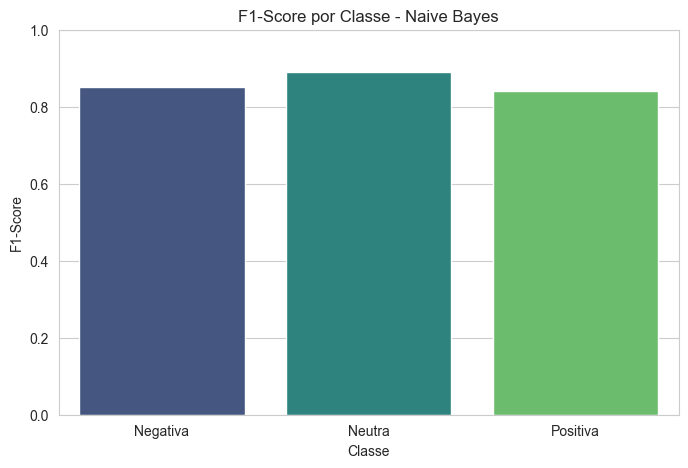


Gerando Matriz de Confusão...


Matriz 'matriz_confusao_nb.png' salva em ../../resultados/

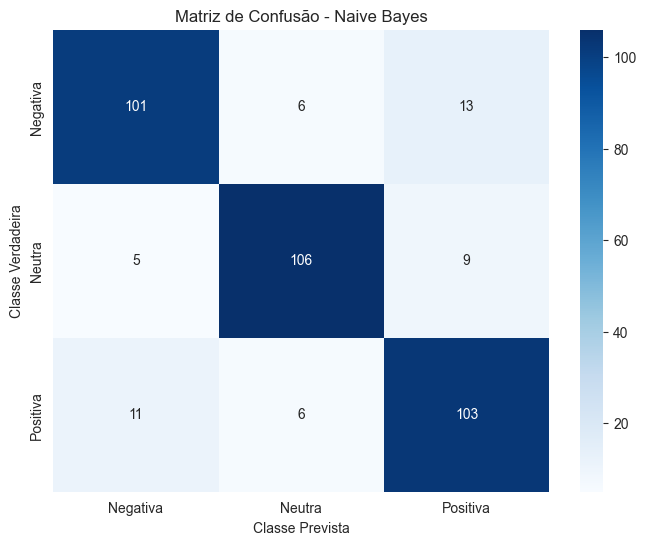


Resultados do Naive Bayes salvos.


In [9]:
print("--- Etapa 3.3: Treinamento - Naive Bayes (Multinomial) ---")

# 1. Inicializar o modelo
model_nb = MultinomialNB()

# 2. Treinar o modelo
print("Treinando o modelo Naive Bayes...")
model_nb.fit(X_train_tfidf, y_train)
print("Treinamento concluído.")

# 3. Fazer previsões
y_pred_nb = model_nb.predict(X_test_tfidf)

# 4. Gerar Relatório
print("\n--- Relatório de Classificação (Naive Bayes) ---")
print(classification_report(y_test, y_pred_nb))

# 5. Gerar o Relatório como um Dicionário
report_dict_nb = classification_report(y_test, y_pred_nb, output_dict=True)
df_report_nb = pd.DataFrame(report_dict_nb).transpose()
f1_scores_nb = df_report_nb.loc[['Negativa', 'Neutra', 'Positiva'], 'f1-score']

f1_final_nb = report_dict_nb['weighted avg']['f1-score']
print(f"\n--- Veredito (O que importa pro TCC) ---")
print(f"O F1-Score final (ponderado) do modelo foi: {f1_final_nb:.4f} (ou {f1_final_nb*100:.2f}%)")

# 6. Plotar o Gráfico de F1-Score por Classe
pasta_resultados = "../../resultados/"
plt.figure(figsize=(8, 5))
sns.barplot(
    x=f1_scores_nb.index,
    y=f1_scores_nb.values,
    palette='viridis',
    hue=f1_scores_nb.index,
    legend=False
)
plt.title('F1-Score por Classe - Naive Bayes')
plt.xlabel('Classe')
plt.ylabel('F1-Score')
plt.ylim(0, 1.0)
plt.savefig(f"{pasta_resultados}f1_score_por_classe_nb.png")
print(f"Gráfico 'f1_score_por_classe_nb.png' salvo em {pasta_resultados}")
plt.show()

# 7. Gerar Matriz de Confusão
print("\nGerando Matriz de Confusão...")
cm_nb = confusion_matrix(y_test, y_pred_nb)
labels = sorted(y.unique())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.title('Matriz de Confusão - Naive Bayes')
plt.xlabel('Classe Prevista')
plt.ylabel('Classe Verdadeira')
plt.savefig(f"{pasta_resultados}matriz_confusao_nb.png")
print(f"Matriz 'matriz_confusao_nb.png' salva em {pasta_resultados}")
plt.show()

# 8. Armazena os resultados no nosso dicionário
resultados_modelos['Naive Bayes'] = {
    'Acurácia': report_dict_nb['accuracy'],
    'Precisão': report_dict_nb['weighted avg']['precision'],
    'Recall': report_dict_nb['weighted avg']['recall'],
    'F1-Score': f1_final_nb
}

print("\nResultados do Naive Bayes salvos.")

--- Etapa 3.4: Treinamento - SVM (Linear) ---
Treinando o modelo SVM Linear...
Treinamento concluído.

--- Relatório de Classificação (SVM Linear) ---
              precision    recall  f1-score   support

    Negativa       0.89      0.82      0.86       120
      Neutra       0.85      0.91      0.88       120
    Positiva       0.84      0.85      0.85       120

    accuracy                           0.86       360
   macro avg       0.86      0.86      0.86       360
weighted avg       0.86      0.86      0.86       360

F1-Score final (ponderado): 0.8609 (86.09%)


Gráfico salvo em ../../resultados/f1_score_por_classe_svm.png


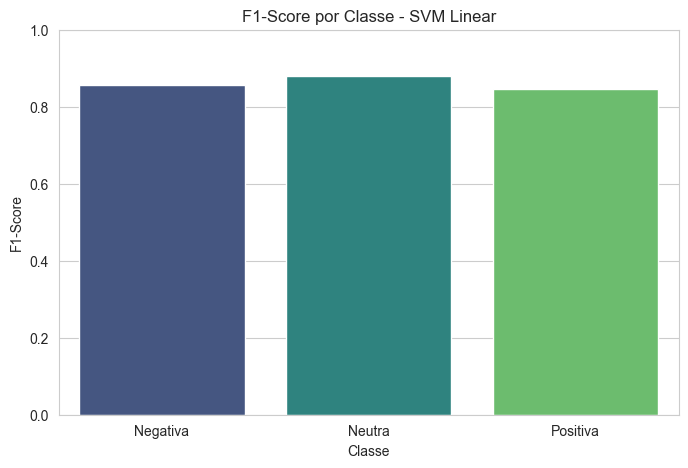

Matriz salva em ../../resultados/matriz_confusao_svm.png


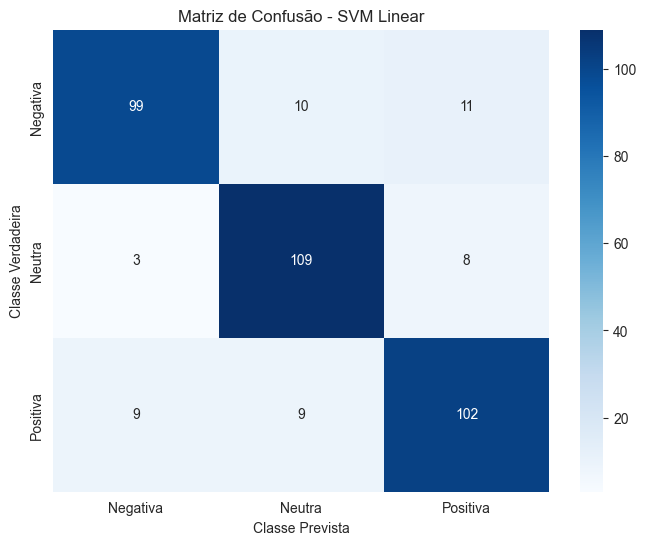


Resultados do SVM Linear salvos.


In [10]:
print("--- Etapa 3.4: Treinamento - SVM (Linear) ---")

# 1. Inicializar e Treinar
model_svm = LinearSVC(random_state=RANDOM_SEED, max_iter=5000)
print("Treinando o modelo SVM Linear...")
model_svm.fit(X_train_tfidf, y_train)
print("Treinamento concluído.")

# 2. Fazer previsões
y_pred_svm = model_svm.predict(X_test_tfidf)

# 3. Gerar Relatório
print("\n--- Relatório de Classificação (SVM Linear) ---")
print(classification_report(y_test, y_pred_svm))

# 4. Métricas
report_dict_svm = classification_report(y_test, y_pred_svm, output_dict=True)
df_report_svm = pd.DataFrame(report_dict_svm).transpose()
f1_scores_svm = df_report_svm.loc[['Negativa', 'Neutra', 'Positiva'], 'f1-score']

f1_final_svm = report_dict_svm['weighted avg']['f1-score']
print(f"F1-Score final (ponderado): {f1_final_svm:.4f} ({f1_final_svm*100:.2f}%)")

# 5. Gráfico F1 por classe
pasta_resultados = "../../resultados/"
plt.figure(figsize=(8, 5))
sns.barplot(
    x=f1_scores_svm.index,
    y=f1_scores_svm.values,
    palette='viridis',
    hue=f1_scores_svm.index,
    legend=False
)
plt.title('F1-Score por Classe - SVM Linear')
plt.xlabel('Classe')
plt.ylabel('F1-Score')
plt.ylim(0, 1.0)
plt.savefig(f"{pasta_resultados}f1_score_por_classe_svm.png")
print(f"Gráfico salvo em {pasta_resultados}f1_score_por_classe_svm.png")
plt.show()

# 6. Matriz de Confusão
cm_svm = confusion_matrix(y_test, y_pred_svm)
labels = sorted(y.unique())

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.title('Matriz de Confusão - SVM Linear')
plt.xlabel('Classe Prevista')
plt.ylabel('Classe Verdadeira')
plt.savefig(f"{pasta_resultados}matriz_confusao_svm.png")
print(f"Matriz salva em {pasta_resultados}matriz_confusao_svm.png")
plt.show()

# 7. Salvar no dicionário
resultados_modelos['SVM Linear'] = {
    'Acurácia': report_dict_svm['accuracy'],
    'Precisão': report_dict_svm['weighted avg']['precision'],
    'Recall': report_dict_svm['weighted avg']['recall'],
    'F1-Score': f1_final_svm
}

print("\nResultados do SVM Linear salvos.")

In [11]:
print("--- [X] Relatório Final: Comparativo dos Modelos Baseline ---\n")

# 1. PRINTAR NA TELA
for nome_modelo, metricas in resultados_modelos.items():
    print(f"--- {nome_modelo} ---")
    acc = f"{metricas['Acurácia'] * 100:.2f}%"
    pre = f"{metricas['Precisão'] * 100:.2f}%"
    rec = f"{metricas['Recall'] * 100:.2f}%"
    f1  = f"{metricas['F1-Score'] * 100:.2f}%\n"
    print(f" Acurácia: {acc}")
    print(f" Precisão: {pre}")
    print(f" Recall:   {rec}")
    print(f" F1-Score: {f1}")
    print("--------------------------------------\n")

# 2. SALVAR NO ARQUIVO
print("--- Salvando resultados em arquivo... ---")

df_resultados = pd.DataFrame.from_dict(resultados_modelos, orient='index')
df_resultados = df_resultados.round(4)

caminho_arquivo = "../../resultados/baseline_metrics.csv"

try:
    df_resultados.to_csv(caminho_arquivo)
    print(f"✅ Sucesso! Arquivo salvo em: {caminho_arquivo}")
    print("\nConteúdo salvo no CSV:")
    print(df_resultados)
except Exception as e:
    print(f"❌ Erro ao salvar o arquivo: {e}")

--- [X] Relatório Final: Comparativo dos Modelos Baseline ---

--- Regressão Logística ---
 Acurácia: 83.61%
 Precisão: 83.80%
 Recall:   83.61%
 F1-Score: 83.54%

--------------------------------------

--- Naive Bayes ---
 Acurácia: 86.11%
 Precisão: 86.19%
 Recall:   86.11%
 F1-Score: 86.13%

--------------------------------------

--- SVM Linear ---
 Acurácia: 86.11%
 Precisão: 86.21%
 Recall:   86.11%
 F1-Score: 86.09%

--------------------------------------

--- Salvando resultados em arquivo... ---
✅ Sucesso! Arquivo salvo em: ../../resultados/baseline_metrics.csv

Conteúdo salvo no CSV:
                     Acurácia  Precisão  Recall  F1-Score
Regressão Logística    0.8361    0.8380  0.8361    0.8354
Naive Bayes            0.8611    0.8619  0.8611    0.8613
SVM Linear             0.8611    0.8621  0.8611    0.8609


In [12]:
print("--- Etapa 4.1: Validação Cruzada (k-fold) ---")

k_folds = 10

pipeline_nb = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', MultinomialNB())
])

print(f"Rodando Validação Cruzada (k={k_folds}) para Naive Bayes...")
print("Isso pode levar alguns segundos...")

scores = cross_val_score(
    pipeline_nb,
    X,
    y,
    cv=k_folds,
    scoring='f1_weighted'
)

print("\n--- Resultados da Estabilidade ---")
print(f"F1-Scores das {k_folds} rodadas: {scores}")
print(f"Média do F1-Score: {scores.mean():.4f} (ou {scores.mean()*100:.2f}%)")
print(f"Desvio Padrão: +/- {scores.std():.4f}")

if scores.std() < 0.05:
    print("\n>> CONCLUSÃO: O modelo é ESTÁVEL (baixo desvio padrão).")
else:
    print("\n>> CONCLUSÃO: O modelo é INSTÁVEL (alto desvio padrão).")

# Atualizar o arquivo de métricas
try:
    resultados_modelos['NB (Validação Cruzada)'] = {
        'Acurácia': np.nan,
        'Precisão': np.nan,
        'Recall': np.nan,
        'F1-Score': scores.mean()
    }

    df_resultados = pd.DataFrame.from_dict(resultados_modelos, orient='index').round(4)
    df_resultados.to_csv("../../resultados/baseline_metrics.csv")

    print("\n✅ Sucesso! O arquivo 'baseline_metrics.csv' foi atualizado com a Validação Cruzada.")
    print(df_resultados.tail(1))

except NameError:
    print("⚠️ Aviso: Dicionário 'resultados_modelos' não encontrado. O CSV não foi atualizado.")

--- Etapa 4.1: Validação Cruzada (k-fold) ---
Rodando Validação Cruzada (k=10) para Naive Bayes...
Isso pode levar alguns segundos...



--- Resultados da Estabilidade ---


F1-Scores das 10 rodadas: [0.88365016 0.8943887  0.88387829 0.94429063 0.87283377 0.8895798
 0.9066092  0.86635062 0.91090648 0.91070842]
Média do F1-Score: 0.8963 (ou 89.63%)
Desvio Padrão: +/- 0.0215

>> CONCLUSÃO: O modelo é ESTÁVEL (baixo desvio padrão).

✅ Sucesso! O arquivo 'baseline_metrics.csv' foi atualizado com a Validação Cruzada.
                        Acurácia  Precisão  Recall  F1-Score
NB (Validação Cruzada)       NaN       NaN     NaN    0.8963
